In [2]:
import os
# Change to the directory where the script is located to be able to import local modules
os.chdir("..")

In [5]:
from pathlib import Path
cwd = Path.cwd()
print(cwd)

h:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM


# Libraries 

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Check the Index Dataframe 

In [15]:
df_index = pd.read_parquet(cwd/"data"/"index"/"runs.parquet")
print(df_index.shape)
df_index.head()

(48, 13)


,dgp,run_id,path,created_at,git_commit,params,split_file,n,T,p,a,seed,split_seed
0,blackwell_yamauchi,86675482,data\raw\blackwell_yamauchi\86675482,2025-10-17T13:04:55Z,f64031b,"{'T': 50, 'a': 1, 'beta': [-0.5, -0.5], 'dgp':...",data\splits\blackwell_yamauchi\N250_T50_p2_spl...,250,50,2,1,1,42
1,blackwell_yamauchi,30d3ecb7,data\raw\blackwell_yamauchi\30d3ecb7,2025-10-17T13:04:58Z,f64031b,"{'T': 25, 'a': 1, 'beta': [-0.5, -0.5], 'dgp':...",data\splits\blackwell_yamauchi\N250_T25_p2_spl...,250,25,2,1,1,42
2,blackwell_yamauchi,1df78972,data\raw\blackwell_yamauchi\1df78972,2025-10-17T13:05:00Z,f64031b,"{'T': 5, 'a': 1, 'beta': [-0.5, -0.5], 'dgp': ...",data\splits\blackwell_yamauchi\N250_T5_p2_spli...,250,5,2,1,1,42
3,blackwell_yamauchi,e78a6048,data\raw\blackwell_yamauchi\e78a6048,2025-10-17T13:05:04Z,f64031b,"{'T': 50, 'a': 1, 'beta': [-0.5, -0.5, 1.0, -0...",data\splits\blackwell_yamauchi\N250_T50_p4_spl...,250,50,4,1,1,42
4,blackwell_yamauchi,84469d7a,data\raw\blackwell_yamauchi\84469d7a,2025-10-17T13:05:07Z,f64031b,"{'T': 25, 'a': 1, 'beta': [-0.5, -0.5, 1.0, -0...",data\splits\blackwell_yamauchi\N250_T25_p4_spl...,250,25,4,1,1,42


In [17]:
from utils.runs import load_by_params
from itertools import product 

dgp = "blackwell_yamauchi"

rho = [5,10,50] # n/T
params_grid = {
    "n": [int(i * (10/8)) for i in [200, 500, 1000, 3000]],
    "seed": [1], 
    "a": [1,2], 
    "p": [2,4], 
}

T =  {n:[int(n/r) for r in rho] for n in params_grid["n"]}

beta_dict = {2:  [-0.5, -0.5], 4: [-0.5, -0.5, 1.0, -0.5]}
gamma_dict = {2: [1.0, 0.5], 4: [1.0, 0.5, 1.0, 1.0]}

params = {
    "phi": 0.3,
    "tau_F": 1.0, 
    "tau_C": 0.3,
    "mean_x": -0.5, 
    "offdiag": 0.2,
    "sigma_eps": 1.0, 
    "max_lag_x": 0, 
    "max_lag_d": 3,
    "split_seed": 42
    }

treatment_model = "logit"

params["treatment_model"] = treatment_model

df_manifest = []

for n, seed, a, p in product(*params_grid.values()):
  
    for t in T[n]:
        cfg = {"dgp": dgp,"n": n, "T": t, "seed": seed, "a": a, "p": p,
               "beta": beta_dict[p], "gamma": gamma_dict[p], **params}
        
        df, manifest = load_by_params(".", cfg)
        df_manifest.append((df,manifest))

In [18]:
filtered = [(df,manifest) for df,manifest in df_manifest if manifest["params"]["a"]== 2 ]

In [19]:
df,manifest = filtered[3]
for key in ["n","T","p","a"]:
    print(f"{key}: {manifest["params"][key]}")


n: 250
T: 50
p: 4
a: 2


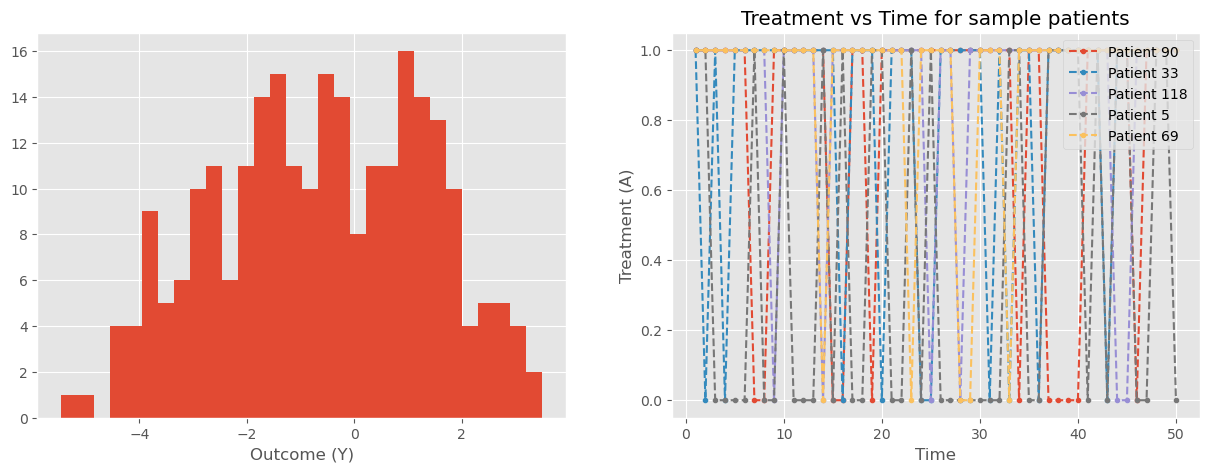

In [20]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

num = 5
seed = 42
sample_ids = df["patient_id"].drop_duplicates().sample(num)
#sample_ids = [train_ids[1881]]
fig,ax = plt.subplots(1,2,figsize = (15,5))
for pid in sample_ids:
    sub = df[df.patient_id == pid]
    #ax[0].plot(sub["t"], sub["Y"], "--.",label = f"Patient {pid}")
    ax[1].plot(sub["t"], sub["D"], "--.",label = f"Patient {pid}")

#ax[0].set_xlabel("Time")
#ax[0].set_ylabel("Outcome (Y)")
#ax[0].set_title("Outcome vs Time for sample patients")
#ax[0].legend()

ax[0].hist(df.Y,bins=30)
ax[0].set_xlabel("Outcome (Y)")
#ax[0].set_title("Outcome vs Time for sample patients")
#ax[0].legend()

ax[1].set_xlabel("Time")
ax[1].set_ylabel("Treatment (A)")
ax[1].set_title("Treatment vs Time for sample patients")
ax[1].legend(loc = "upper right")
plt.show()

In [21]:
import plotly.express as px

fig = px.histogram(
    df, 
    x="D", 
    animation_frame="t",   # animate over time
    nbins=20, 
    title="Distribution of D over time", 
    histnorm="probability",
    width=800,   # width in pixels
    height=600   # height in pixels
)
fig.update_layout(yaxis=dict(autorange=True))
fig.show()


array([[<Axes: title={'center': 'alpha'}>]], dtype=object)

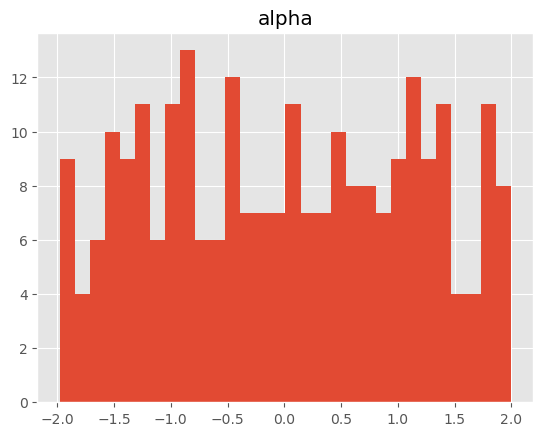

In [36]:
df.drop_duplicates(subset=["patient_id","alpha"], keep="first").hist(column="alpha", bins=30)